# CITS4404 — AI Trading Bot
**Team 4**  
- Bomin Liao 24331475 
- Weishan Li 24746589 
- Ziqi Meng 24645175 
- Chenxiao Jiang 24438869

---

## Project Overview
This notebook implements an AI-driven Bitcoin trading bot optimised using two nature-inspired algorithms:
- **Differential Evolution (DE)**
- **Particle Swarm Optimization (PSO)**

The bot uses technical analysis signals (SMA/EMA crossover) as its trading strategy.  
Parameters are optimised on pre-2020 data and evaluated on post-2020 data.

---

### Notebook Structure
1. Imports & Setup  
2. Data Loading & Preprocessing  
3. Bot Building Blocks (WMA, SMA, EMA, LMA)  
4. Trading Signal & Bot Logic  
5. Evaluation Function  
6. Differential Evolution (DE)  
7. Particle Swarm Optimization (PSO)  
8. Experiments & Results  
9. Final Test on Unseen Data (2020+)  
10. Visualisation & Comparison

## 1. Imports & Setup
This section imports all required Python libraries and sets a global random seed to ensure reproducibility across all experiments.

| Library | Purpose |
|---------|---------|
| `numpy` | Numerical operations, array manipulation, random number generation |
| `pandas` | Data loading, time-series manipulation, results tables |
| `matplotlib` | Plotting price charts, convergence curves, and trade signals |
| `warnings` | Suppress non-critical warnings for cleaner output |

`SEED = 42` is passed to both DE and PSO to ensure that independent runs with the same seed produce identical results, which is important for fair comparison and reproducibility.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Preprocessing

The raw dataset (`btcusd_1-min_data.csv`) contains Bitcoin OHLCV data at 1-minute resolution from 2012 to 2026. Since minute-level granularity introduces noise and would make optimisation prohibitively slow, we resample to **daily close prices** using the last available price of each calendar day.

The data is then split into two non-overlapping sets:

| Split | Period | Days | Purpose |
|-------|--------|------|---------|
| **Train** | 2012-01-01 → 2019-12-31 | 2,922 | Optimise bot parameters |
| **Test** | 2020-01-01 → present | 2,316 | Evaluate generalisation on unseen data |

This mirrors a realistic deployment scenario where the bot is tuned on historical data and then run "live" from 2020 onwards. The test set is kept completely untouched until Section 9.

In [9]:
# Load raw minute-level data
df_raw = pd.read_csv('btcusd_1-min_data.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Timestamp'], unit='s')
df_raw = df_raw.set_index('Date')

# Resample to daily close price
daily = df_raw['Close'].resample('D').last().dropna().reset_index()
daily.columns = ['Date', 'Close']

# Train / Test split
train_df = daily[daily['Date'] < '2020-01-01'].reset_index(drop=True)
test_df  = daily[daily['Date'] >= '2020-01-01'].reset_index(drop=True)

train_prices = train_df['Close'].values
test_prices  = test_df['Close'].values

print(f'Train: {len(train_prices)} days  ({train_df.Date.min().date()} to {train_df.Date.max().date()})')
print(f'Test:  {len(test_prices)} days  ({test_df.Date.min().date()} to {test_df.Date.max().date()})')

Train: 2922 days  (2012-01-01 to 2019-12-31)
Test:  2316 days  (2020-01-01 to 2026-05-04)


The chart below visualises the full price history used in this project. The **training period (blue)** covers Bitcoin's early growth phase up to ~\$14,000, while the **test period (red)** captures the highly volatile 2020–2026 bull and bear cycles including the 2021 all-time high (~\$69,000) and the 2022 crash.

This contrast between training and test conditions makes generalisation a genuine challenge — a bot optimised purely on pre-2020 trends may not perform well in the more volatile post-2020 market.

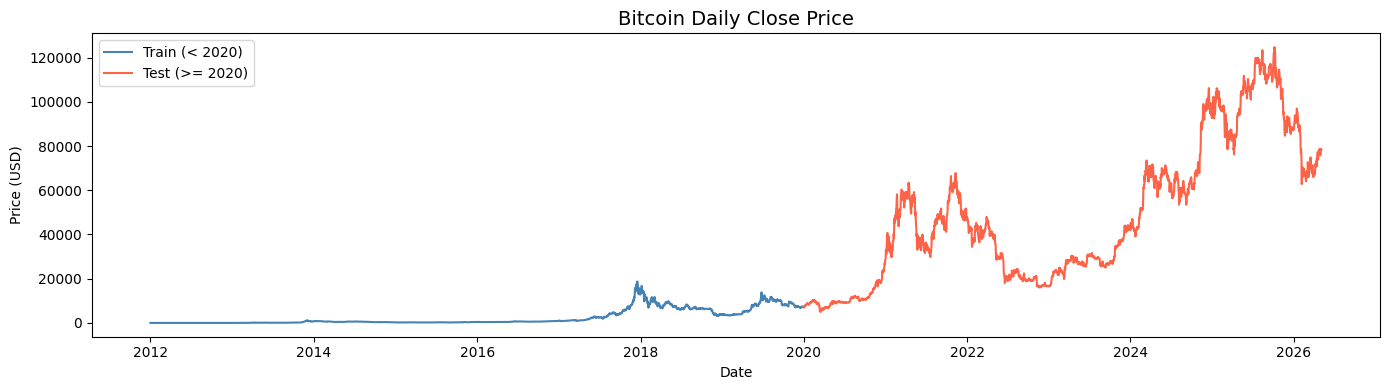

In [10]:
# Plot full price history
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['Date'], train_prices, label='Train (< 2020)', color='steelblue')
ax.plot(test_df['Date'],  test_prices,  label='Test (>= 2020)', color='tomato')
ax.set_title('Bitcoin Daily Close Price', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. Bot Building Blocks — Weighted Moving Averages

The bot's trading signals are derived from **Weighted Moving Averages (WMAs)** — a class of filters that smooth the price series by computing a weighted sum of the most recent `N` prices. Three filter types are implemented, each differing in how they weight past observations:

**Simple Moving Average (SMA)**  
All `N` past prices receive equal weight: $w_k = \frac{1}{N}$. This is the most straightforward filter but reacts slowly to recent price changes.

**Linear-Weighted Moving Average (LMA)**  
Weights decrease linearly with age: $w_k = 1 - \frac{k}{N}$, normalised to sum to 1. More recent prices have greater influence than older ones.

**Exponential Moving Average (EMA)**  
Weights decay exponentially: $w_k = \alpha(1-\alpha)^k$, where $\alpha = \frac{2}{N+1}$. This gives the strongest emphasis to the most recent prices and is widely used in practice (e.g. MACD is built from two EMAs).

The `wma(prices, N, filter_type)` function applies any of these filters via convolution, returning a smoothed series of the same length as `prices` (with `NaN` for the first `N-1` entries where insufficient history exists).

The choice of filter type and window size `N` are the **parameters that DE and PSO will optimise**.

In [11]:
def sma_filter(N):
    """Simple Moving Average filter of length N."""
    return np.ones(N) / N

def lma_filter(N):
    """Linear-Weighted Moving Average filter of length N."""
    weights = np.array([1 - k / N for k in range(N)])
    return weights / weights.sum()

def ema_filter(N, alpha=None):
    """Exponential Moving Average filter of length N."""
    if alpha is None:
        alpha = 2 / (N + 1)
    weights = np.array([alpha * (1 - alpha) ** k for k in range(N)])
    return weights / weights.sum()

def wma(prices, N, filter_type='sma'):
    """
    Compute weighted moving average of prices.
    filter_type: 'sma', 'lma', or 'ema'
    Returns array of same length as prices (NaN for first N-1 values).
    """
    if filter_type == 'sma':
        kernel = sma_filter(N)
    elif filter_type == 'lma':
        kernel = lma_filter(N)
    elif filter_type == 'ema':
        kernel = ema_filter(N)
    else:
        raise ValueError(f'Unknown filter_type: {filter_type}')

    result = np.full(len(prices), np.nan)
    for i in range(N - 1, len(prices)):
        result[i] = np.dot(kernel, prices[i - N + 1: i + 1][::-1])
    return result

# --- Quick sanity check ---
P = train_prices[:200]
sma10 = wma(P, 10, 'sma')
ema10 = wma(P, 10, 'ema')
print('SMA(10) last 3:', sma10[-3:])
print('EMA(10) last 3:', ema10[-3:])

SMA(10) last 3: [7.184 7.36  7.593]
EMA(10) last 3: [7.40462259 7.63893551 7.9703781 ]


## 4. Trading Signal & Bot Logic

The bot uses a **dual moving average crossover** strategy — one of the most widely adopted technical trading signals. Two moving averages of different window lengths are computed simultaneously:

- **Short MA** (`N_short`): reacts quickly to recent price changes
- **Long MA** (`N_long`): tracks the broader trend, responds more slowly

A signal is generated when the two lines cross:

| Event | Condition | Signal | Action |
|-------|-----------|--------|--------|
| Golden Cross | Short MA crosses **above** Long MA | `+1` | **Buy** — uptrend beginning |
| Death Cross | Short MA crosses **below** Long MA | `−1` | **Sell** — downtrend beginning |
| No crossover | No change in sign of difference | `0` | **Hold** |

The crossover is detected by monitoring the sign change of `diff = short_ma − long_ma` between consecutive timesteps. A transition from `diff ≤ 0` to `diff > 0` triggers a buy, and the reverse triggers a sell.

The values of `N_short` and `N_long` (and the filter type) are the **free parameters** of the bot — finding the combination that maximises profit on the training data is the optimisation problem that DE and PSO are tasked with solving.

In [12]:
def generate_signals(prices, N_short, N_long, filter_type='sma'):
    """
    Generate buy/sell signals from a crossover of two moving averages.
    Buy  (+1): short MA crosses above long MA
    Sell (-1): short MA crosses below long MA
    Hold  (0): no crossover
    """
    short_ma = wma(prices, N_short, filter_type)
    long_ma  = wma(prices, N_long,  filter_type)

    diff = short_ma - long_ma
    signals = np.zeros(len(prices), dtype=int)

    for i in range(1, len(prices)):
        if np.isnan(diff[i]) or np.isnan(diff[i - 1]):
            continue
        if diff[i - 1] <= 0 and diff[i] > 0:
            signals[i] = 1   # Buy
        elif diff[i - 1] >= 0 and diff[i] < 0:
            signals[i] = -1  # Sell

    return signals, short_ma, long_ma

# --- Sanity check ---
sigs, sma_s, sma_l = generate_signals(train_prices[:500], 10, 30, 'sma')
buys  = np.sum(sigs == 1)
sells = np.sum(sigs == -1)
print(f'Buy signals: {buys},  Sell signals: {sells}')

Buy signals: 7,  Sell signals: 7


## 5. Evaluation Function

The evaluation function is the **fitness function** used by DE and PSO to judge how good a set of parameters is. It simulates the bot's complete trading history on a given price series and returns the final portfolio value in USD.

**Trading rules:**
- The bot starts with `$10,000` cash and no BTC
- On a **Buy** signal: all available cash is used to purchase BTC (minus transaction cost)
- On a **Sell** signal: all BTC holdings are liquidated back to cash (minus transaction cost)
- Only one position can be held at a time — the bot is either fully in cash or fully in BTC
- A **transaction cost of 0.1%** is applied to every trade to reflect realistic exchange fees

**Final portfolio value** is calculated as:

$$\text{Value} = \text{cash} + \text{btc} \times \text{price}_{\text{last}}$$

If the bot ends the period holding BTC, the remaining position is valued at the last closing price.

**Parameter validation** ensures `N_short ≥ 2` and `N_long > N_short` at all times, preventing degenerate configurations that would produce no signals. This is important because DE and PSO operate in continuous space and may propose non-integer or invalid values.

This function is called thousands of times during optimisation — once per candidate solution per iteration — so its computational efficiency directly affects the total runtime of the experiment.

In [13]:
def evaluate_bot(prices, N_short, N_long, filter_type='sma',
                 initial_cash=10000.0, transaction_cost=0.001):
    """
    Simulate trading and return final portfolio value.
    - Starts with initial_cash, no BTC held.
    - On Buy:  spend all cash to buy BTC.
    - On Sell: sell all BTC for cash.
    - transaction_cost: fraction deducted per trade (e.g. 0.001 = 0.1%).
    Returns final portfolio value in USD.
    """
    # Validate params
    N_short = max(2, int(round(N_short)))
    N_long  = max(N_short + 1, int(round(N_long)))

    signals, _, _ = generate_signals(prices, N_short, N_long, filter_type)

    cash = initial_cash
    btc  = 0.0
    position = 0  # 0 = no position, 1 = holding BTC

    for i in range(len(prices)):
        price = prices[i]
        if signals[i] == 1 and position == 0 and cash > 0:
            # Buy
            btc = (cash * (1 - transaction_cost)) / price
            cash = 0.0
            position = 1
        elif signals[i] == -1 and position == 1 and btc > 0:
            # Sell
            cash = btc * price * (1 - transaction_cost)
            btc = 0.0
            position = 0

    # Final portfolio value
    final_value = cash + btc * prices[-1]
    return final_value

# --- Sanity check ---
val = evaluate_bot(train_prices, N_short=10, N_long=30, filter_type='sma')
print(f'Final portfolio value (SMA 10/30, train): ${val:,.2f}')

Final portfolio value (SMA 10/30, train): $14,552,037.48


## 6. Differential Evolution (DE)

In [1]:
# TODO: Implement DE from scratch
# Parameters to optimise: [N_short, N_long]
# Bounds: N_short in [2, 50], N_long in [10, 200]

def differential_evolution(prices, bounds, pop_size=20, max_iter=100,
                            F=0.8, CR=0.9, filter_type='sma', seed=SEED):
    """
    Differential Evolution for trading bot parameter optimisation.
    Maximises evaluate_bot() return value.

    Args:
        prices:      array of close prices
        bounds:      list of (min, max) tuples for each parameter
        pop_size:    population size
        max_iter:    maximum iterations
        F:           scaling factor (mutation)
        CR:          crossover rate
        filter_type: 'sma', 'lma', or 'ema'
        seed:        random seed

    Returns:
        best_params: best [N_short, N_long] found
        best_value:  portfolio value at best params
        history:     list of best values per iteration
    """
    np.random.seed(seed)
    n_params = len(bounds)

    # --- Step 1: Initialise population ---
    # TODO: fill in
    pass

    # --- Step 2: Evaluate initial population ---
    # TODO: fill in
    pass

    # --- Step 3: Main loop ---
    history = []
    for iteration in range(max_iter):
        for i in range(pop_size):
            # Mutation: select 3 distinct random individuals != i
            # TODO: fill in

            # Crossover
            # TODO: fill in

            # Clip to bounds
            # TODO: fill in

            # Selection
            # TODO: fill in
            pass

        # Record best this iteration
        # TODO: fill in
        pass

    return None, None, history  # placeholder

print('DE scaffold ready.')

NameError: name 'SEED' is not defined

## 7. Particle Swarm Optimization (PSO)



PSO maintains a swarm of particles, each representing a candidate solution 
in the parameter space [N_short, N_long]. At each iteration, particle 
velocities are updated using:

$$v_{id} \leftarrow w \cdot v_{id} + c_1 r_1 (pbest_{id} - x_{id}) + c_2 r_2 (gbest_d - x_{id})$$

where:
- **w = 0.7**: inertia weight, controls momentum
- **c1 = 2.0**: cognitive coefficient, attraction to personal best
- **c2 = 2.0**: social coefficient, attraction to global best
- **r1, r2**: random values in [0, 1]

The algorithm maximises the evaluate_bot() fitness function over the 
training data (2012–2019).


In [ ]:
def particle_swarm_optimization(prices, bounds, n_particles=20, max_iter=100,
                                 w=0.7, c1=2.0, c2=2.0,
                                 filter_type='sma', seed=SEED):
    """
    Particle Swarm Optimization for trading bot parameter optimisation.
    Maximises evaluate_bot() return value.

    Args:
        prices:      array of close prices
        bounds:      list of (min, max) tuples for each parameter
        n_particles: swarm size
        max_iter:    maximum iterations
        w:           inertia weight
        c1:          cognitive coefficient (personal best)
        c2:          social coefficient (global best)
        filter_type: 'sma', 'lma', or 'ema'
        seed:        random seed

    Returns:
        best_params: best [N_short, N_long] found
        best_value:  portfolio value at best params
        history:     list of best values per iteration
    """
    np.random.seed(seed)
    n_params = len(bounds)
    bounds = np.array(bounds)  # shape (n_params, 2)

    # --- Step 1: Initialise positions and velocities ---
    # positions: each particle randomly placed within bounds
    positions = np.array([
        [np.random.uniform(bounds[d, 0], bounds[d, 1]) for d in range(n_params)]
        for _ in range(n_particles)
    ])

    # velocities: initialised to small random values
    vel_range = bounds[:, 1] - bounds[:, 0]
    velocities = np.array([
        [np.random.uniform(-vel_range[d], vel_range[d]) for d in range(n_params)]
        for _ in range(n_particles)
    ])

    # --- Step 2: Evaluate initial swarm ---
    fitness = np.array([
        evaluate_bot(prices, positions[i, 0], positions[i, 1], filter_type)
        for i in range(n_particles)
    ])

    # Initialise personal bests
    pbest_pos = positions.copy()
    pbest_val = fitness.copy()

    # Initialise global best
    gbest_idx = np.argmax(pbest_val)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_val = pbest_val[gbest_idx]

    # --- Step 3: Main loop ---
    history = []
    for iteration in range(max_iter):
        for i in range(n_particles):

            # Update velocity
            # v = w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)
            r1 = np.random.random(n_params)
            r2 = np.random.random(n_params)
            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_pos[i] - positions[i])
                + c2 * r2 * (gbest_pos    - positions[i])
            )

            # Update position
            positions[i] = positions[i] + velocities[i]

            # Clip to bounds
            positions[i] = np.clip(positions[i], bounds[:, 0], bounds[:, 1])

            # Evaluate and update pbest / gbest
            val = evaluate_bot(prices, positions[i, 0], positions[i, 1], filter_type)

            if val > pbest_val[i]:
                pbest_val[i] = val
                pbest_pos[i] = positions[i].copy()

            if val > gbest_val:
                gbest_val = val
                gbest_pos = positions[i].copy()

        # Record best this iteration
        history.append(gbest_val)

    best_params = [int(round(gbest_pos[0])), int(round(gbest_pos[1]))]
    return best_params, gbest_val, history

print('PSO implemented successfully.')

## 8. Experiments & Results

In [ ]:
# ── Experiment Configuration ──────────────────────────────────────────
BOUNDS      = [(2, 50), (10, 200)]  # [N_short, N_long]
POP_SIZE    = 20
MAX_ITER    = 100
N_RUNS      = 5                      # multiple runs for statistical reliability

# DE hyperparameters
DE_F  = 0.8
DE_CR = 0.9

# PSO hyperparameters
PSO_W  = 0.7
PSO_C1 = 2.0
PSO_C2 = 2.0

print('Experiment config ready.')
print(f'  Search space : N_short in {BOUNDS[0]}, N_long in {BOUNDS[1]}')
print(f'  Population   : {POP_SIZE}')
print(f'  Max iters    : {MAX_ITER}')
print(f'  Runs         : {N_RUNS}')


### 8.1 Single Run — SMA Filter

In [ ]:
# ── Single run with SMA filter ────────────────────────────────────────
FILTER = 'sma'

print('Running DE (SMA)...')
de_params, de_value, de_history = differential_evolution(
    train_prices, BOUNDS,
    pop_size=POP_SIZE, max_iter=MAX_ITER,
    F=DE_F, CR=DE_CR,
    filter_type=FILTER, seed=SEED
)
print(f'  Best params : N_short={de_params[0]}, N_long={de_params[1]}')
print(f'  Train value : ${de_value:,.2f}')

print()
print('Running PSO (SMA)...')
pso_params, pso_value, pso_history = particle_swarm_optimization(
    train_prices, BOUNDS,
    n_particles=POP_SIZE, max_iter=MAX_ITER,
    w=PSO_W, c1=PSO_C1, c2=PSO_C2,
    filter_type=FILTER, seed=SEED
)
print(f'  Best params : N_short={pso_params[0]}, N_long={pso_params[1]}')
print(f'  Train value : ${pso_value:,.2f}')


In [ ]:
# ── Convergence curves (single run) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(de_history,  label=f'DE  (best=${de_value:,.0f})',  color='steelblue', linewidth=2)
ax.plot(pso_history, label=f'PSO (best=${pso_value:,.0f})', color='tomato',    linewidth=2, linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Convergence Curve: DE vs PSO (SMA, Training Data)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_sma.png', dpi=150)
plt.show()
print('Saved: convergence_sma.png')


### 8.2 Multiple Runs — Statistical Comparison

In [ ]:
# ── Multiple runs to assess consistency ───────────────────────────────
de_results  = []
pso_results = []

print(f'Running {N_RUNS} independent runs each...')
for run in range(N_RUNS):
    s = SEED + run
    _, val_de,  _ = differential_evolution(
        train_prices, BOUNDS,
        pop_size=POP_SIZE, max_iter=MAX_ITER,
        F=DE_F, CR=DE_CR,
        filter_type=FILTER, seed=s
    )
    _, val_pso, _ = particle_swarm_optimization(
        train_prices, BOUNDS,
        n_particles=POP_SIZE, max_iter=MAX_ITER,
        w=PSO_W, c1=PSO_C1, c2=PSO_C2,
        filter_type=FILTER, seed=s
    )
    de_results.append(val_de)
    pso_results.append(val_pso)
    print(f'  Run {run+1}: DE=${val_de:>12,.2f}  PSO=${val_pso:>12,.2f}')

print()
print(f'DE  — Mean: ${np.mean(de_results):>12,.2f}  Std: ${np.std(de_results):>10,.2f}  Best: ${max(de_results):>12,.2f}')
print(f'PSO — Mean: ${np.mean(pso_results):>12,.2f}  Std: ${np.std(pso_results):>10,.2f}  Best: ${max(pso_results):>12,.2f}')


### 8.3 Filter Type Comparison — SMA vs EMA vs LMA

In [ ]:
# ── Compare filter types ──────────────────────────────────────────────
filter_results = {}

for ft in ['sma', 'ema', 'lma']:
    p_de,  v_de,  _ = differential_evolution(
        train_prices, BOUNDS,
        pop_size=POP_SIZE, max_iter=MAX_ITER,
        F=DE_F, CR=DE_CR, filter_type=ft, seed=SEED
    )
    p_pso, v_pso, _ = particle_swarm_optimization(
        train_prices, BOUNDS,
        n_particles=POP_SIZE, max_iter=MAX_ITER,
        w=PSO_W, c1=PSO_C1, c2=PSO_C2, filter_type=ft, seed=SEED
    )
    filter_results[ft] = {
        'de_params': p_de, 'de_value': v_de,
        'pso_params': p_pso, 'pso_value': v_pso
    }
    print(f'[{ft.upper()}] DE: N=({p_de[0]},{p_de[1]}) ${v_de:,.2f} | PSO: N=({p_pso[0]},{p_pso[1]}) ${v_pso:,.2f}')


In [ ]:
# ── Bar chart: filter comparison ──────────────────────────────────────
filters  = ['SMA', 'EMA', 'LMA']
de_vals  = [filter_results[f]['de_value']  for f in ['sma','ema','lma']]
pso_vals = [filter_results[f]['pso_value'] for f in ['sma','ema','lma']]

x = np.arange(len(filters))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, de_vals,  width, label='DE',  color='steelblue')
bars2 = ax.bar(x + width/2, pso_vals, width, label='PSO', color='tomato')
ax.set_xlabel('Filter Type')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Training Performance by Filter Type')
ax.set_xticks(x)
ax.set_xticklabels(filters)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)
for bar in bars1: ax.annotate(f'${bar.get_height():,.0f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
for bar in bars2: ax.annotate(f'${bar.get_height():,.0f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('filter_comparison.png', dpi=150)
plt.show()
print('Saved: filter_comparison.png')


## 9. Final Test on Unseen Data (2020+)

In [ ]:
# ── Select best config from training experiments ──────────────────────
# Pick best filter type based on DE training performance
best_filter = max(filter_results, key=lambda f: filter_results[f]['de_value'])
best_de_params  = filter_results[best_filter]['de_params']
best_pso_params = filter_results[best_filter]['pso_params']

print(f'Best filter type : {best_filter.upper()}')
print(f'DE  best params  : N_short={best_de_params[0]}, N_long={best_de_params[1]}')
print(f'PSO best params  : N_short={best_pso_params[0]}, N_long={best_pso_params[1]}')


In [ ]:
# ── Evaluate on test set (2020+) ──────────────────────────────────────
INITIAL_CASH = 10_000.0

de_test_value  = evaluate_bot(test_prices, best_de_params[0],  best_de_params[1],  best_filter, INITIAL_CASH)
pso_test_value = evaluate_bot(test_prices, best_pso_params[0], best_pso_params[1], best_filter, INITIAL_CASH)

# Baselines
buy_hold_value = INITIAL_CASH * (test_prices[-1] / test_prices[0])

# ROI %
de_roi  = (de_test_value  - INITIAL_CASH) / INITIAL_CASH * 100
pso_roi = (pso_test_value - INITIAL_CASH) / INITIAL_CASH * 100
bh_roi  = (buy_hold_value - INITIAL_CASH) / INITIAL_CASH * 100

print('='*55)
print(f'{"Algorithm":<20} {"Final Value":>14}  {"ROI":>8}')
print('-'*55)
print(f'{"DE":<20} ${de_test_value:>13,.2f}  {de_roi:>7.1f}%')
print(f'{"PSO":<20} ${pso_test_value:>13,.2f}  {pso_roi:>7.1f}%')
print(f'{"Buy & Hold":<20} ${buy_hold_value:>13,.2f}  {bh_roi:>7.1f}%')
print('='*55)
print(f'Initial investment: ${INITIAL_CASH:,.2f}')
print(f'Test period: {test_df.Date.min().date()} to {test_df.Date.max().date()}')


In [ ]:
# ── Portfolio value over time (test period) ───────────────────────────
def simulate_portfolio(prices, N_short, N_long, filter_type, initial_cash=10000.0, tc=0.001):
    """Return portfolio value at each timestep for plotting."""    N_short = max(2, int(round(N_short)))
    N_long  = max(N_short + 1, int(round(N_long)))
    signals, _, _ = generate_signals(prices, N_short, N_long, filter_type)

    cash, btc, position = initial_cash, 0.0, 0
    portfolio = []

    for i in range(len(prices)):
        price = prices[i]
        if signals[i] == 1 and position == 0 and cash > 0:
            btc = (cash * (1 - tc)) / price
            cash = 0.0
            position = 1
        elif signals[i] == -1 and position == 1 and btc > 0:
            cash = btc * price * (1 - tc)
            btc = 0.0
            position = 0
        portfolio.append(cash + btc * price)

    return np.array(portfolio)

de_portfolio  = simulate_portfolio(test_prices, best_de_params[0],  best_de_params[1],  best_filter)
pso_portfolio = simulate_portfolio(test_prices, best_pso_params[0], best_pso_params[1], best_filter)
bh_portfolio  = INITIAL_CASH * (test_prices / test_prices[0])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['Date'], de_portfolio,  label=f'DE  (ROI={de_roi:.1f}%)',  color='steelblue', linewidth=2)
ax.plot(test_df['Date'], pso_portfolio, label=f'PSO (ROI={pso_roi:.1f}%)', color='tomato',    linewidth=2, linestyle='--')
ax.plot(test_df['Date'], bh_portfolio,  label=f'Buy & Hold (ROI={bh_roi:.1f}%)', color='grey', linewidth=1.5, linestyle=':')
ax.set_title('Portfolio Value Over Time — Test Data (2020+)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('portfolio_test.png', dpi=150)
plt.show()
print('Saved: portfolio_test.png')


## 10. Visualisation & Comparison

### 10.1 Trade Signals on Test Data

In [ ]:
# ── Plot buy/sell signals on price chart ──────────────────────────────
def plot_trades(prices, dates, N_short, N_long, filter_type, title):
    signals, short_ma, long_ma = generate_signals(prices, N_short, N_long, filter_type)
    buy_idx  = np.where(signals ==  1)[0]
    sell_idx = np.where(signals == -1)[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, prices,   label='Price',                   color='black',     linewidth=1)
    ax.plot(dates, short_ma, label=f'Short MA ({N_short}d)',  color='steelblue', linewidth=1.5)
    ax.plot(dates, long_ma,  label=f'Long MA  ({N_long}d)',   color='orange',    linewidth=1.5)
    ax.scatter(dates[buy_idx],  prices[buy_idx],  marker='^', color='green', s=80, zorder=5, label=f'Buy  ({len(buy_idx)})')
    ax.scatter(dates[sell_idx], prices[sell_idx], marker='v', color='red',   s=80, zorder=5, label=f'Sell ({len(sell_idx)})')
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = title.split('(')[0].strip().lower().replace(' ','_') + '.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved: {fname}')

plot_trades(test_prices, test_df['Date'].values,
            best_de_params[0],  best_de_params[1],  best_filter,
            f'DE Bot — Test Data (N_short={best_de_params[0]}, N_long={best_de_params[1]}, {best_filter.upper()})')

plot_trades(test_prices, test_df['Date'].values,
            best_pso_params[0], best_pso_params[1], best_filter,
            f'PSO Bot — Test Data (N_short={best_pso_params[0]}, N_long={best_pso_params[1]}, {best_filter.upper()})')


### 10.2 Final Summary Table

In [ ]:
# ── Full summary table ────────────────────────────────────────────────
summary = pd.DataFrame({
    'Algorithm'      : ['DE', 'PSO', 'Buy & Hold'],
    'Filter'         : [best_filter.upper(), best_filter.upper(), '-'],
    'N_short'        : [best_de_params[0],  best_pso_params[0],  '-'],
    'N_long'         : [best_de_params[1],  best_pso_params[1],  '-'],
    'Train Value ($)': [f'{filter_results[best_filter]["de_value"]:,.2f}',
                        f'{filter_results[best_filter]["pso_value"]:,.2f}', '-'],
    'Test Value ($)' : [f'{de_test_value:,.2f}',  f'{pso_test_value:,.2f}',  f'{buy_hold_value:,.2f}'],
    'ROI (%)'        : [f'{de_roi:.1f}%',          f'{pso_roi:.1f}%',         f'{bh_roi:.1f}%'],
})
print(summary.to_string(index=False))


### 10.3 Statistical Summary (Multiple Runs)

In [ ]:
# ── Stats from multiple runs ──────────────────────────────────────────
stats = pd.DataFrame({
    'Algorithm' : ['DE', 'PSO'],
    'Mean ($)'  : [f'{np.mean(de_results):,.2f}',  f'{np.mean(pso_results):,.2f}'],
    'Std ($)'   : [f'{np.std(de_results):,.2f}',   f'{np.std(pso_results):,.2f}'],
    'Best ($)'  : [f'{max(de_results):,.2f}',       f'{max(pso_results):,.2f}'],
    'Worst ($)' : [f'{min(de_results):,.2f}',       f'{min(pso_results):,.2f}'],
})
print('Training Performance across', N_RUNS, 'runs:')
print(stats.to_string(index=False))

# Box plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([de_results, pso_results], labels=['DE', 'PSO'],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title(f'Distribution of Results over {N_RUNS} Runs (Training)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_runs.png', dpi=150)
plt.show()
print('Saved: boxplot_runs.png')
